In [3]:
# 简单 PyTorch RNN 示例

#用 `nn.RNN` 学习正弦序列的**下一步预测**：输入过去 10 个时刻的值，预测下一个值。

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# 超参数
SEQ_LEN = 10
HIDDEN_SIZE = 32
BATCH_SIZE = 32
EPOCHS = 30
LR = 0.01

torch.manual_seed(42)

# 生成数据: x[t] = sin(t), 用前 SEQ_LEN 个点预测下一个点
T = torch.arange(0, 200 * 0.1, 0.1)
series = torch.sin(T).unsqueeze(1)  # shape: (200, 1)

xs, ys = [], []
for i in range(len(series) - SEQ_LEN):
    xs.append(series[i:i + SEQ_LEN])
    ys.append(series[i + SEQ_LEN])
xs = torch.stack(xs)   # (N, SEQ_LEN, 1)
ys = torch.stack(ys)   # (N, 1)

dataset = TensorDataset(xs, ys)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)


class SimpleRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=32):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)      # out: (batch, seq_len, hidden)
        last = out[:, -1, :]      # 取最后一个时间步
        return self.fc(last)


model = SimpleRNN(hidden_size=HIDDEN_SIZE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

for epoch in range(1, EPOCHS + 1):
    total_loss = 0.0
    for batch_x, batch_y in loader:
        pred = model(batch_x)
        loss = criterion(pred, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d} | loss = {total_loss / len(loader):.6f}")

Epoch 01 | loss = 0.396837
Epoch 05 | loss = 0.004859
Epoch 10 | loss = 0.000398
Epoch 15 | loss = 0.000089
Epoch 20 | loss = 0.000034
Epoch 25 | loss = 0.000023
Epoch 30 | loss = 0.000011


真实值 -> 预测值
 0.8415 ->  0.8423
 0.8912 ->  0.8911
 0.9320 ->  0.9306
 0.9636 ->  0.9605
 0.9854 ->  0.9810
 0.9975 ->  0.9921
 0.9996 ->  0.9940
 0.9917 ->  0.9867


e:\conda\envs\rl-driving\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\conda\envs\rl-driving\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\conda\envs\rl-driving\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\conda\envs\rl-driving\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\conda\envs\rl-driving\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu San

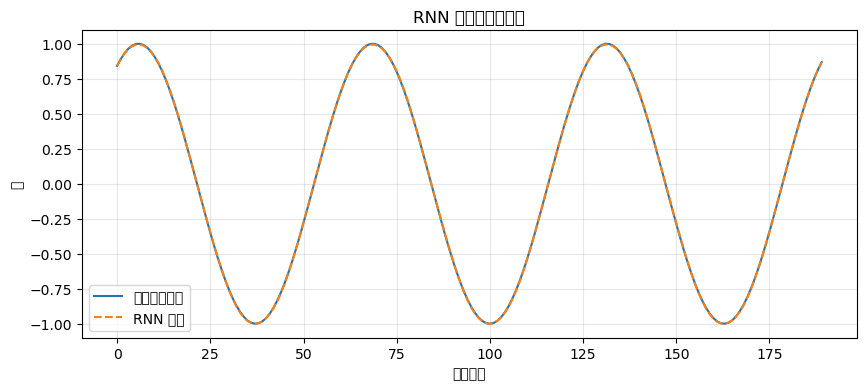

In [5]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    preds = model(xs).squeeze(1).numpy()
    targets = ys.squeeze(1).numpy()

# 打印部分预测结果
print("真实值 -> 预测值")
for i in range(8):
    print(f"{targets[i]: .4f} -> {preds[i]: .4f}")

# 可视化: 真实序列 vs RNN 预测
plt.figure(figsize=(10, 4))
plt.plot(targets, label="真实下一个值")
plt.plot(preds, label="RNN 预测", linestyle="--")
plt.title("RNN 下一步预测结果")
plt.xlabel("样本索引")
plt.ylabel("值")
plt.legend()
plt.grid(alpha=0.3)
plt.show()